# Weak GPU Complexity Benchmark: Mat32 / top_q / N

目标是稳定识别经验复杂度、定位瓶颈、比较算法在弱 GPU 上的拐点，不追求单点最快。

本 notebook 只回答四个问题：

- Q1: `gpu_v1_topq0` 的总时间随 `N` 如何增长。
- Q2: `gpu_v3_topq` 相比 `gpu_v1_topq0` 在不同 `N` 下更快还是更慢，拐点在哪里。
- Q3: 时间增长主要来自哪一段：`precompute/eigenspace/solve/predict`。
- Q4: 随着 `N` 增大，`top_q>0` 的优势是在扩大还是缩小。

实验拆成三层：

1. 端到端时间 vs `N`
2. 分阶段时间 vs `N`
3. 迭代统计 vs `N`

控制变量固定：

- 数据分布固定（2D + Mat32 + 固定采样分布）
- `eps` 固定
- `cg_tol` 固定
- `N_test` 固定
- 每条曲线内部 `top_q` 固定

输出要求：

- 每次 run 结果会 `print`
- 同时保存 `raw csv`
- 聚合统计保存 `summary csv`
- 图像保存到 `png`


In [ ]:
## For github import
import os
import sys

GITHUB_USER = "Yifiwifi"
REPO_NAME = "EFGP-Eigenpro"
SUB_DIR = "efgp_eigenpro_py"
PROJECT_PATH = f"/content/{REPO_NAME}"

if not os.path.exists(PROJECT_PATH):
    !git clone https://github.com/{GITHUB_USER}/{REPO_NAME}.git
else:
    %cd {PROJECT_PATH}
    !git pull origin main

CODE_ROOT = os.path.join(PROJECT_PATH, SUB_DIR)
if CODE_ROOT not in sys.path:
    sys.path.append(CODE_ROOT)

print("Checking runtime dependencies")
!pip install cufinufft cupy-cuda12x --extra-index-url https://pypi.nvidia.com

requirements_path = os.path.join(CODE_ROOT, "requirements.txt")
if os.path.exists(requirements_path):
    !pip install -r {requirements_path}

sanity_check_path = os.path.join(CODE_ROOT, "gpu/sanity_check")
if os.path.exists(sanity_check_path):
    os.chdir(sanity_check_path)
    print("cwd:", os.getcwd())
else:
    print("sanity_check path not found:", sanity_check_path)

# Refresh runtime library path for some Colab images
os.environ["LD_LIBRARY_PATH"] = "/usr/local/lib:" + os.environ.get("LD_LIBRARY_PATH", "")
!ldconfig /usr/local/lib

print("=" * 40)
try:
    import torch
    import cupy as cp
    import cufinufft
    cp.cuda.Stream.null.synchronize()
    print("PyTorch:", torch.__version__)
    print("GPU:", torch.cuda.get_device_name(0))
    print("cufinufft import ok")
except Exception as e:
    print("runtime check failed:", e)
print("=" * 40)


In [1]:
import gc
import os
import sys
import time
import json
import traceback
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_here = Path.cwd().resolve()
_candidates = [
    _here,
    _here.parent,
    _here.parent.parent,
    _here.parent.parent.parent,
    Path("D:/NU/ML"),
]
for p in _candidates:
    pkg_dir = p / "efgp_eigenpro_py"
    if pkg_dir.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))
        break

from efgp_eigenpro_py.kernels import make_matern
from efgp_eigenpro_py.efgp_solver import EFGPSolver
from efgp_eigenpro_py.benchmark import make_dataset, make_test_set, true_func_2d, compute_rmse
from efgp_eigenpro_py.gpu.backends import BackendConfig
from efgp_eigenpro_py.gpu.versions import GPURunConfig, run_v1_pure_efgp, run_v3_full_gpu_eigenspace
from efgp_eigenpro_py.gpu.v3_eigenspace import EigenspaceConfig

try:
    import cupy as cp
except Exception:
    cp = None

np.set_printoptions(precision=6, suppress=True)
print("cwd:", os.getcwd())
print("sys.path[0]:", sys.path[0])
print("cupy available:", cp is not None)


cwd: d:\NU\ML\efgp_eigenpro_py\gpu\sanity_check
sys.path[0]: D:\NU\ML
cupy available: True


In [2]:
# ---- Fixed controls ----
DIM = 2
LENGTHSCALE = 0.1
NU = 1.5
REG_LAMBDA = 0.1
EPS = 1e-5
SOLVE_TOL = 1e-6
GPU_MAXITER = 3000
GPU_NUFFT = "auto"
L2_SCALED = True

N_TEST = 1000
NOISE = 0.02
SEED_TRAIN_BASE = 20260421
SEED_TEST = 1

# Recommended weak-GPU first round
N_LIST = [100_000, 300_000]                    # [100_000, 300_000, 1_000_000, 3_000_000, 10_000_000]
MODE_SPECS = [
    {"mode": "gpu_v1_topq0", "top_q": 0},
    {"mode": "gpu_v3_topq", "top_q": 32},
    {"mode": "gpu_v3_topq", "top_q": 64},
]

REPEATS_POLICY = {
    "small": 20,   # N <= 1e6
    "mid": 10,     # N == 3e6
    "large": 5,    # N >= 1e7
}

WARMUP_N = 100_000
WARMUP_SEED = 7
CLEAR_POOL_PER_N = True

V3_OVERSAMPLE = 16
V3_N_ITER = 3

RUN_TAG = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = Path("outputs") / f"weak_gpu_complexity_{RUN_TAG}"
OUT_DIR.mkdir(parents=True, exist_ok=True)
RAW_CSV = OUT_DIR / "raw_runs.csv"
SUMMARY_CSV = OUT_DIR / "summary_by_mode_n.csv"
ENV_JSON = OUT_DIR / "env_info.json"

print("RUN_TAG:", RUN_TAG)
print("OUT_DIR:", OUT_DIR)
print("N_LIST:", N_LIST)
print("MODE_SPECS:", MODE_SPECS)


RUN_TAG: 20260422_001236
OUT_DIR: outputs\weak_gpu_complexity_20260422_001236
N_LIST: [100000, 300000]
MODE_SPECS: [{'mode': 'gpu_v1_topq0', 'top_q': 0}, {'mode': 'gpu_v3_topq', 'top_q': 32}, {'mode': 'gpu_v3_topq', 'top_q': 64}]


In [3]:
kernel = make_matern(lengthscale=LENGTHSCALE, nu=NU, dim=DIM, variance=1.0)
x_test, y_test = make_test_set(DIM, N_TEST, true_func_2d, seed=SEED_TEST)


def _sync_gpu():
    if cp is not None:
        cp.cuda.Stream.null.synchronize()


def _clear_state(clear_pool=False):
    _sync_gpu()
    gc.collect()
    if cp is not None and clear_pool:
        cp.get_default_memory_pool().free_all_blocks()
        cp.get_default_pinned_memory_pool().free_all_blocks()
    _sync_gpu()


def _gpu_mem_used_gb():
    if cp is None:
        return np.nan
    try:
        free_b, total_b = cp.cuda.runtime.memGetInfo()
        return float((total_b - free_b) / (1024 ** 3))
    except Exception:
        return np.nan


def _device_name():
    if cp is None:
        return "cpu"
    try:
        return cp.cuda.runtime.getDeviceProperties(0)["name"].decode("utf-8")
    except Exception:
        return "unknown_gpu"


def _pick_repeats(n_train: int) -> int:
    if n_train <= 1_000_000:
        return int(REPEATS_POLICY["small"])
    if n_train >= 10_000_000:
        return int(REPEATS_POLICY["large"])
    return int(REPEATS_POLICY["mid"])


def _collect_env_info():
    info = {
        "timestamp": datetime.now().isoformat(),
        "python": sys.version,
        "platform": sys.platform,
        "device_name": _device_name(),
        "eps": EPS,
        "solve_tol": SOLVE_TOL,
        "gpu_maxiter": GPU_MAXITER,
        "nufft_mode": GPU_NUFFT,
        "l2_scaled": L2_SCALED,
        "dim": DIM,
        "kernel": "Mat32",
        "nu": NU,
        "lengthscale": LENGTHSCALE,
        "reg_lambda": REG_LAMBDA,
        "n_test": N_TEST,
        "n_list": [int(v) for v in N_LIST],
        "mode_specs": MODE_SPECS,
    }
    try:
        import cupy
        info["cupy"] = cupy.__version__
    except Exception:
        info["cupy"] = "unavailable"
    try:
        import cufinufft
        info["cufinufft"] = getattr(cufinufft, "__version__", "unknown")
    except Exception:
        info["cufinufft"] = "unavailable"
    return info


def _extract_common_metrics(diag: dict):
    return {
        "cg_iters": int(diag.get("cg_iters", -1)),
        "cg_relres": float(diag.get("cg_relres", np.nan)),
        "n_matvec": int(diag.get("n_matvec", 0)),
        "t_matvec_total": float(diag.get("t_matvec_total", np.nan)),
        "n_precond": int(diag.get("n_precond", 0)),
        "t_precond_total": float(diag.get("t_precond_total", np.nan)),
        "time_precompute": float(diag.get("time_precompute", np.nan)),
        "time_eigenspace": float(diag.get("time_eigenspace", 0.0)),
        "time_precond_build": float(diag.get("time_precond_build", 0.0)),
        "time_solve": float(diag.get("time_solve", np.nan)),
        "time_predict": float(diag.get("time_predict", np.nan)),
        "nufft_stage": str(diag.get("nufft_stage", "")),
        "device_name": str(diag.get("device_name", "")),
    }


def _run_case_once(mode: str, top_q: int, n_train: int, seed_train: int, warmup_only=False) -> dict:
    x_train, y_train = make_dataset(DIM, n_train, true_func_2d, noise=NOISE, seed=seed_train)

    solver = EFGPSolver(
        kernel=kernel,
        reg_lambda=REG_LAMBDA,
        eps=EPS,
        nufft_tol=1e-10,
        l2scaled=L2_SCALED,
    )
    cfg = GPURunConfig(
        reg_lambda=REG_LAMBDA,
        tol=SOLVE_TOL,
        maxiter=GPU_MAXITER,
        chunk_size=None,
        debug_finite_checks=False,
        backend=BackendConfig(nufft=GPU_NUFFT),
    )

    _sync_gpu()
    mem_before = _gpu_mem_used_gb()
    t0 = time.perf_counter()
    if mode == "gpu_v1_topq0":
        out = run_v1_pure_efgp(solver, x_train, y_train, cfg)
    elif mode == "gpu_v3_topq":
        if int(top_q) <= 0:
            raise ValueError("top_q must be > 0 for gpu_v3_topq")
        eig_cfg = EigenspaceConfig(
            q_max=int(top_q),
            block_size=int(top_q + V3_OVERSAMPLE),
            n_iter=int(V3_N_ITER),
        )
        out = run_v3_full_gpu_eigenspace(solver, x_train, y_train, cfg, eig_cfg)
    else:
        raise ValueError(f"unsupported mode: {mode}")
    _sync_gpu()
    t1 = time.perf_counter()
    mem_after = _gpu_mem_used_gb()

    if warmup_only:
        return {"status": "warmup_done"}

    state_cpu = solver.precompute(x_train, y_train)
    if cp is None:
        beta_cpu = np.asarray(out.beta_gpu)
    else:
        beta_cpu = cp.asnumpy(out.beta_gpu)
    yhat = solver.predict(x_test, beta_cpu, state_cpu)
    rmse = float(compute_rmse(yhat, y_test))

    diag = out.diagnostics
    row = {
        "run_id": f"{RUN_TAG}_{mode}_q{int(top_q)}_N{int(n_train)}_{seed_train}",
        "timestamp": datetime.now().isoformat(),
        "mode": mode,
        "N": int(n_train),
        "eps": float(EPS),
        "top_q": int(top_q),
        "reg_lambda": float(REG_LAMBDA),
        "cg_tol": float(SOLVE_TOL),
        "wall_s_total": float(t1 - t0),
        "rmse_test": float(rmse),
        "peak_mem_gb": float(np.nanmax([mem_before, mem_after])),
        "status": "ok",
        "error": "",
    }
    row.update(_extract_common_metrics(diag))
    return row


def _run_warmup_for_mode(mode: str, top_q: int, n_ref: int):
    n_warm = int(min(n_ref, WARMUP_N))
    print(f"warmup start: mode={mode}, top_q={top_q}, N={n_warm}")
    _clear_state(clear_pool=False)
    _ = _run_case_once(mode=mode, top_q=top_q, n_train=n_warm, seed_train=WARMUP_SEED, warmup_only=True)
    _clear_state(clear_pool=False)
    print(f"warmup done: mode={mode}, top_q={top_q}")


env_info = _collect_env_info()
ENV_JSON.write_text(json.dumps(env_info, indent=2), encoding="utf-8")
print("env info saved:", ENV_JSON)
print(json.dumps(env_info, indent=2))


env info saved: outputs\weak_gpu_complexity_20260422_001236\env_info.json
{
  "timestamp": "2026-04-22T00:12:39.686173",
  "python": "3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:20:11) [MSC v.1938 64 bit (AMD64)]",
  "platform": "win32",
  "device_name": "NVIDIA GeForce RTX 3050 Laptop GPU",
  "eps": 1e-05,
  "solve_tol": 1e-06,
  "gpu_maxiter": 3000,
  "nufft_mode": "auto",
  "l2_scaled": true,
  "dim": 2,
  "kernel": "Mat32",
  "nu": 1.5,
  "lengthscale": 0.1,
  "reg_lambda": 0.1,
  "n_test": 1000,
  "n_list": [
    100000,
    300000
  ],
  "mode_specs": [
    {
      "mode": "gpu_v1_topq0",
      "top_q": 0
    },
    {
      "mode": "gpu_v3_topq",
      "top_q": 32
    },
    {
      "mode": "gpu_v3_topq",
      "top_q": 64
    }
  ],
  "cupy": "13.3.0",
  "cufinufft": "unavailable"
}


In [4]:
rows = []

for spec in MODE_SPECS:
    _run_warmup_for_mode(spec["mode"], int(spec["top_q"]), n_ref=int(N_LIST[0]))

for n_train in N_LIST:
    print("=" * 80)
    print(f"N={n_train} start")

    if CLEAR_POOL_PER_N:
        _clear_state(clear_pool=True)

    for spec in MODE_SPECS:
        mode = str(spec["mode"])
        top_q = int(spec["top_q"])
        repeats = _pick_repeats(int(n_train))

        print("-" * 80)
        print(f"mode={mode}, top_q={top_q}, repeats={repeats}")

        for rep in range(repeats):
            seed_train = int(SEED_TRAIN_BASE + rep)
            try:
                _clear_state(clear_pool=False)
                row = _run_case_once(
                    mode=mode,
                    top_q=top_q,
                    n_train=int(n_train),
                    seed_train=seed_train,
                    warmup_only=False,
                )
                row["repeat_idx"] = int(rep)
                row["repeat_count"] = int(repeats)
                rows.append(row)

                print(
                    f"ok rep={rep:02d} N={n_train} mode={mode} q={top_q} "
                    f"wall={row['wall_s_total']:.4f}s solve={row['time_solve']:.4f}s "
                    f"iter={row['cg_iters']} rmse={row['rmse_test']:.6e}"
                )
            except Exception as e:
                tb = traceback.format_exc()
                err_row = {
                    "run_id": f"{RUN_TAG}_{mode}_q{top_q}_N{n_train}_rep{rep}",
                    "timestamp": datetime.now().isoformat(),
                    "mode": mode,
                    "N": int(n_train),
                    "eps": float(EPS),
                    "top_q": int(top_q),
                    "reg_lambda": float(REG_LAMBDA),
                    "cg_tol": float(SOLVE_TOL),
                    "repeat_idx": int(rep),
                    "repeat_count": int(repeats),
                    "wall_s_total": np.nan,
                    "time_precompute": np.nan,
                    "time_eigenspace": np.nan,
                    "time_precond_build": np.nan,
                    "time_solve": np.nan,
                    "time_predict": np.nan,
                    "cg_iters": np.nan,
                    "cg_relres": np.nan,
                    "n_matvec": np.nan,
                    "t_matvec_total": np.nan,
                    "n_precond": np.nan,
                    "t_precond_total": np.nan,
                    "rmse_test": np.nan,
                    "peak_mem_gb": np.nan,
                    "nufft_stage": "",
                    "device_name": _device_name(),
                    "status": "error",
                    "error": f"{type(e).__name__}: {e}",
                    "error_traceback": tb,
                }
                rows.append(err_row)
                print(f"error rep={rep:02d} N={n_train} mode={mode} q={top_q}: {type(e).__name__}: {e}")

        df_partial = pd.DataFrame(rows)
        df_partial.to_csv(RAW_CSV, index=False)
        print("partial raw csv saved:", RAW_CSV, "rows=", len(df_partial))

raw_df = pd.DataFrame(rows)
raw_df.to_csv(RAW_CSV, index=False)
print("final raw csv:", RAW_CSV)
print("raw rows:", len(raw_df))

with pd.option_context("display.max_rows", 200, "display.max_columns", 200):
    display(raw_df.tail(min(len(raw_df), 20)))


warmup start: mode=gpu_v1_topq0, top_q=0, N=100000
warmup done: mode=gpu_v1_topq0, top_q=0
warmup start: mode=gpu_v3_topq, top_q=32, N=100000
warmup done: mode=gpu_v3_topq, top_q=32
warmup start: mode=gpu_v3_topq, top_q=64, N=100000
warmup done: mode=gpu_v3_topq, top_q=64
N=100000 start
--------------------------------------------------------------------------------
mode=gpu_v1_topq0, top_q=0, repeats=20
ok rep=00 N=100000 mode=gpu_v1_topq0 q=0 wall=1.3094s solve=1.2315s iter=400 rmse=2.596762e-03
ok rep=01 N=100000 mode=gpu_v1_topq0 q=0 wall=1.3264s solve=1.2525s iter=396 rmse=2.700423e-03
ok rep=02 N=100000 mode=gpu_v1_topq0 q=0 wall=1.3388s solve=1.2623s iter=404 rmse=2.518388e-03
ok rep=03 N=100000 mode=gpu_v1_topq0 q=0 wall=1.4025s solve=1.3180s iter=400 rmse=2.613098e-03
ok rep=04 N=100000 mode=gpu_v1_topq0 q=0 wall=1.2962s solve=1.2200s iter=396 rmse=2.589463e-03
ok rep=05 N=100000 mode=gpu_v1_topq0 q=0 wall=1.3174s solve=1.2473s iter=397 rmse=2.508256e-03
ok rep=06 N=100000 mod

,run_id,timestamp,mode,N,eps,top_q,reg_lambda,cg_tol,wall_s_total,rmse_test,peak_mem_gb,status,error,cg_iters,cg_relres,n_matvec,t_matvec_total,n_precond,t_precond_total,time_precompute,time_eigenspace,time_precond_build,time_solve,time_predict,nufft_stage,device_name,repeat_idx,repeat_count
100,20260422_001236_gpu_v3_topq_q64_N300000_20260421,2026-04-22T00:15:58.820375,gpu_v3_topq,300000,0.00001,64,0.1,0.000001,1.961027,0.001813,1.461035,ok,,188,9.197270e-07,189,0.317114,188,0.212236,0.083607,1.101013,0.000300,0.753831,0.020141,cpu_finufft,NVIDIA GeForce RTX 3050 Laptop GPU,0,20
101,20260422_001236_gpu_v3_topq_q64_N300000_20260422,2026-04-22T00:16:00.979622,gpu_v3_topq,300000,0.00001,64,0.1,0.000001,1.962598,0.001873,1.461035,ok,,188,9.914119e-07,189,0.337480,188,0.198171,0.089499,1.093429,0.000246,0.759023,0.018131,cpu_finufft,NVIDIA GeForce RTX 3050 Laptop GPU,1,20
102,20260422_001236_gpu_v3_topq_q64_N300000_20260423,2026-04-22T00:16:03.186150,gpu_v3_topq,300000,0.00001,64,0.1,0.000001,2.008495,0.001847,1.461035,ok,,194,9.976557e-07,195,0.339011,194,0.238826,0.083360,1.096708,0.000347,0.808032,0.017686,cpu_finufft,NVIDIA GeForce RTX 3050 Laptop GPU,2,20
103,20260422_001236_gpu_v3_topq_q64_N300000_20260424,2026-04-22T00:16:05.452647,gpu_v3_topq,300000,0.00001,64,0.1,0.000001,2.061973,0.001770,1.461035,ok,,197,9.981972e-07,198,0.343447,197,0.233273,0.084765,1.148475,0.000242,0.805925,0.020369,cpu_finufft,NVIDIA GeForce RTX 3050 Laptop GPU,3,20
104,20260422_001236_gpu_v3_topq_q64_N300000_20260425,2026-04-22T00:16:07.674632,gpu_v3_topq,300000,0.00001,64,0.1,0.000001,2.021361,0.001906,1.461035,ok,,197,8.824593e-07,198,0.344123,197,0.227308,0.091946,1.111835,0.000249,0.793242,0.017668,cpu_finufft,NVIDIA GeForce RTX 3050 Laptop GPU,4,20
105,20260422_001236_gpu_v3_topq_q64_N300000_20260426,2026-04-22T00:16:09.896396,gpu_v3_topq,300000,0.00001,64,0.1,0.000001,2.023781,0.001739,1.461035,ok,,197,8.280079e-07,198,0.367525,197,0.206562,0.089479,1.106581,0.000249,0.803135,0.021956,cpu_finufft,NVIDIA GeForce RTX 3050 Laptop GPU,5,20
106,20260422_001236_gpu_v3_topq_q64_N300000_20260427,2026-04-22T00:16:12.131997,gpu_v3_topq,300000,0.00001,64,0.1,0.000001,2.037211,0.001884,1.461035,ok,,201,8.967524e-07,202,0.344564,201,0.220007,0.086806,1.106993,0.000369,0.821344,0.019459,cpu_finufft,NVIDIA GeForce RTX 3050 Laptop GPU,6,20
107,20260422_001236_gpu_v3_topq_q64_N300000_20260428,2026-04-22T00:16:14.339706,gpu_v3_topq,300000,0.00001,64,0.1,0.000001,2.013649,0.001721,1.461035,ok,,198,9.441682e-07,199,0.330409,198,0.232024,0.082095,1.107299,0.000334,0.799774,0.021410,cpu_finufft,NVIDIA GeForce RTX 3050 Laptop GPU,7,20
108,20260422_001236_gpu_v3_topq_q64_N300000_20260429,2026-04-22T00:16:16.543960,gpu_v3_topq,300000,0.00001,64,0.1,0.000001,2.006044,0.001797,1.461035,ok,,197,9.740090e-07,198,0.350109,197,0.218060,0.088028,1.106504,0.000255,0.790988,0.018163,cpu_finufft,NVIDIA GeForce RTX 3050 Laptop GPU,8,20
109,20260422_001236_gpu_v3_topq_q64_N300000_20260430,2026-04-22T00:16:18.759808,gpu_v3_topq,300000,0.00001,64,0.1,0.000001,2.022654,0.001792,1.461035,ok,,201,8.690128e-07,202,0.351626,201,0.226312,0.087478,1.105740,0.000317,0.807047,0.018818,cpu_finufft,NVIDIA GeForce RTX 3050 Laptop GPU,9,20


In [6]:
ok_df = raw_df[raw_df["status"] == "ok"].copy()

if ok_df.empty:
    raise RuntimeError("no successful runs, cannot aggregate")

metrics = [
    "wall_s_total",
    "time_precompute",
    "time_eigenspace",
    "time_precond_build",
    "time_solve",
    "time_predict",
    "cg_iters",
    "t_matvec_total",
    "t_precond_total",
    "rmse_test",
    "peak_mem_gb",
]


def _quantile(x, q):
    s = pd.to_numeric(x, errors="coerce")
    if s.notna().sum() == 0:
        return np.nan
    return float(s.quantile(q))


group_cols = ["mode", "top_q", "N", "eps"]
gb = ok_df.groupby(group_cols, dropna=False)

parts = []
for m in metrics:
    part = gb[m].agg(["median", "mean", "std"]).reset_index()
    part = part.rename(columns={
        "median": f"{m}_median",
        "mean": f"{m}_mean",
        "std": f"{m}_std",
    })

    q10 = gb[m].apply(lambda s: _quantile(s, 0.10)).reset_index(name=f"{m}_p10")
    q90 = gb[m].apply(lambda s: _quantile(s, 0.90)).reset_index(name=f"{m}_p90")

    part = part.merge(q10, on=group_cols, how="left")
    part = part.merge(q90, on=group_cols, how="left")
    parts.append(part)

summary_df = parts[0]
for p in parts[1:]:
    keep_cols = [c for c in p.columns if c not in group_cols]
    summary_df = summary_df.merge(p[group_cols + keep_cols], on=group_cols, how="left")

count_df = raw_df.groupby(["mode", "top_q", "N", "eps"], as_index=False).agg(
    repeat_count=("run_id", "count"),
    fail_count=("status", lambda x: int((x != "ok").sum())),
)
summary_df = summary_df.merge(count_df, on=["mode", "top_q", "N", "eps"], how="left")

summary_df = summary_df.sort_values(["mode", "top_q", "N"]).reset_index(drop=True)
summary_df.to_csv(SUMMARY_CSV, index=False)

print("summary csv:", SUMMARY_CSV)
print("summary rows:", len(summary_df))

# local slopes on median wall time
summary_df["logN"] = np.log(summary_df["N"].astype(float))
summary_df["logT"] = np.log(summary_df["wall_s_total_median"].astype(float))
summary_df["local_alpha"] = np.nan

for (mode, top_q), idx in summary_df.groupby(["mode", "top_q"]).groups.items():
    ids = list(idx)
    for i in range(len(ids) - 1):
        i0, i1 = ids[i], ids[i + 1]
        dlogn = summary_df.loc[i1, "logN"] - summary_df.loc[i0, "logN"]
        dlogt = summary_df.loc[i1, "logT"] - summary_df.loc[i0, "logT"]
        summary_df.loc[i1, "local_alpha"] = float(dlogt / dlogn) if dlogn != 0 else np.nan

summary_df.to_csv(SUMMARY_CSV, index=False)

main_cols = [
    "mode", "top_q", "N", "eps",
    "wall_s_total_median", "wall_s_total_p10", "wall_s_total_p90",
    "time_precompute_median", "time_eigenspace_median", "time_solve_median", "time_predict_median",
    "cg_iters_median", "t_matvec_total_median", "t_precond_total_median", "rmse_test_median",
    "peak_mem_gb_median", "repeat_count", "fail_count", "local_alpha",
]

with pd.option_context("display.max_rows", 200, "display.max_columns", 200):
    display(summary_df[main_cols])


summary csv: outputs\weak_gpu_complexity_20260422_001236\summary_by_mode_n.csv
summary rows: 6


,mode,top_q,N,eps,wall_s_total_median,wall_s_total_p10,wall_s_total_p90,time_precompute_median,time_eigenspace_median,time_solve_median,time_predict_median,cg_iters_median,t_matvec_total_median,t_precond_total_median,rmse_test_median,peak_mem_gb_median,repeat_count,fail_count,local_alpha
0,gpu_v1_topq0,0,100000,0.00001,1.308410,1.238930,1.398390,0.059388,0.000000,1.233451,0.012589,400.0,0.811784,NaN,0.002584,0.865332,20,0,NaN
1,gpu_v1_topq0,0,300000,0.00001,1.669120,1.609205,1.735022,0.083222,0.000000,1.563991,0.019725,576.0,1.051699,NaN,0.001806,0.888770,20,0,0.221628
2,gpu_v3_topq,32,100000,0.00001,1.609770,1.556482,1.656248,0.057333,0.632682,0.900260,0.011256,213.0,0.404137,0.208839,0.002584,1.105566,20,0,NaN
3,gpu_v3_topq,32,300000,0.00001,1.898869,1.833768,1.960162,0.084834,0.597402,1.195693,0.018615,306.5,0.542778,0.275070,0.001806,1.129004,20,0,0.150342
4,gpu_v3_topq,64,100000,0.00001,1.865693,1.817116,1.877218,0.054382,1.171268,0.623614,0.010807,138.0,0.255028,0.174682,0.002584,1.437598,20,0,NaN
5,gpu_v3_topq,64,300000,0.00001,2.020782,1.975126,2.089626,0.086440,1.107146,0.802271,0.019417,197.0,0.344344,0.222032,0.001807,1.461035,20,0,0.072685


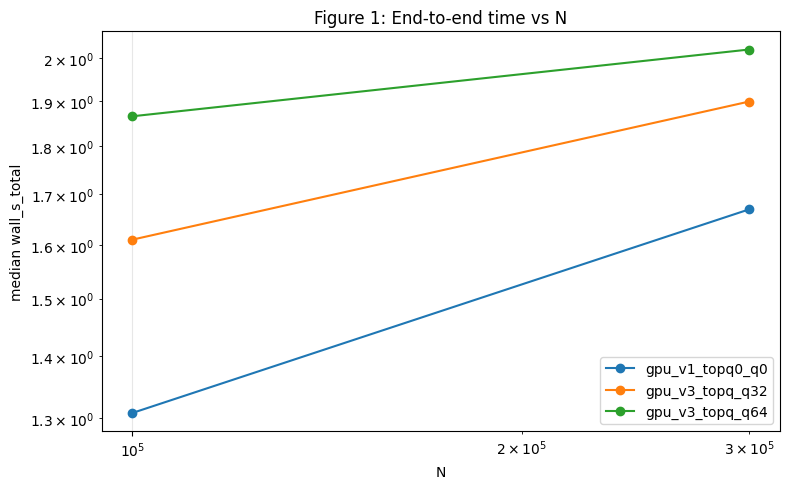

saved: outputs\weak_gpu_complexity_20260422_001236\plots\fig1_total_time_vs_n_loglog.png


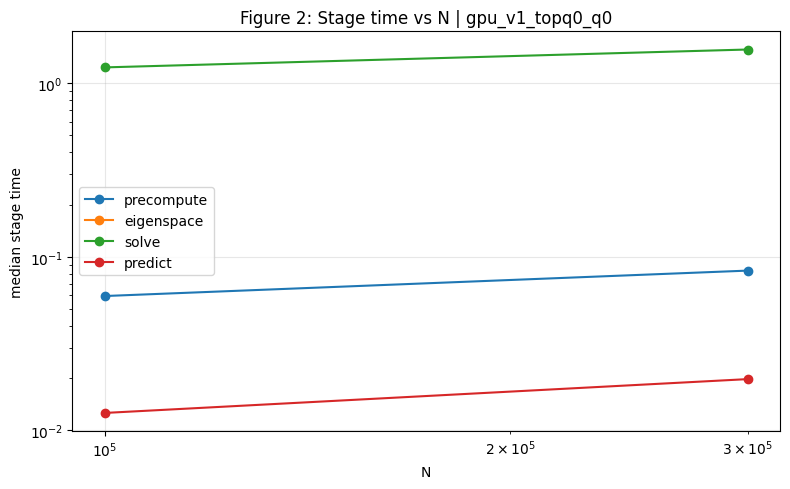

saved: outputs\weak_gpu_complexity_20260422_001236\plots\fig2_stage_vs_n_gpu_v1_topq0_q0.png


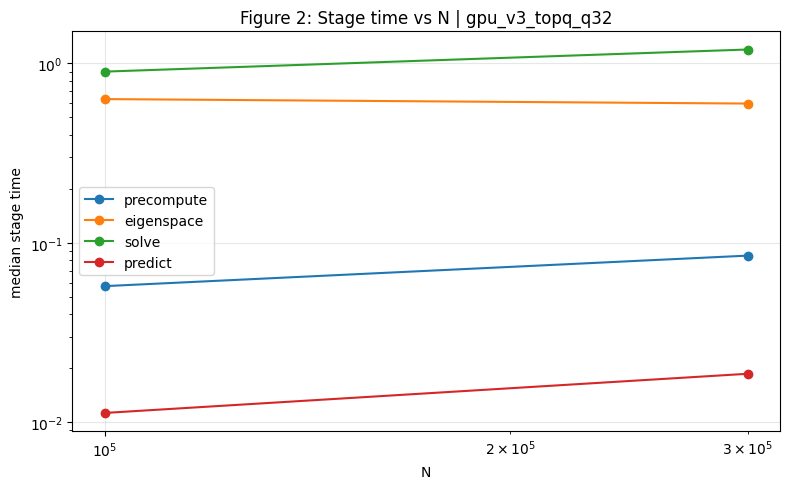

saved: outputs\weak_gpu_complexity_20260422_001236\plots\fig2_stage_vs_n_gpu_v3_topq_q32.png


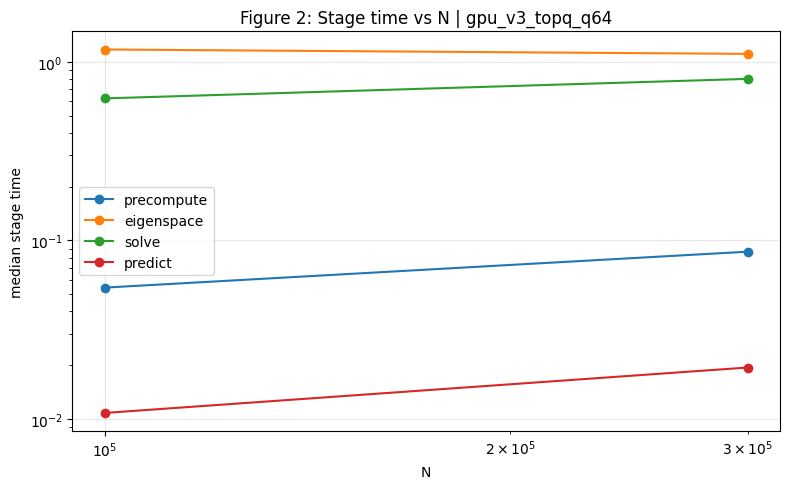

saved: outputs\weak_gpu_complexity_20260422_001236\plots\fig2_stage_vs_n_gpu_v3_topq_q64.png


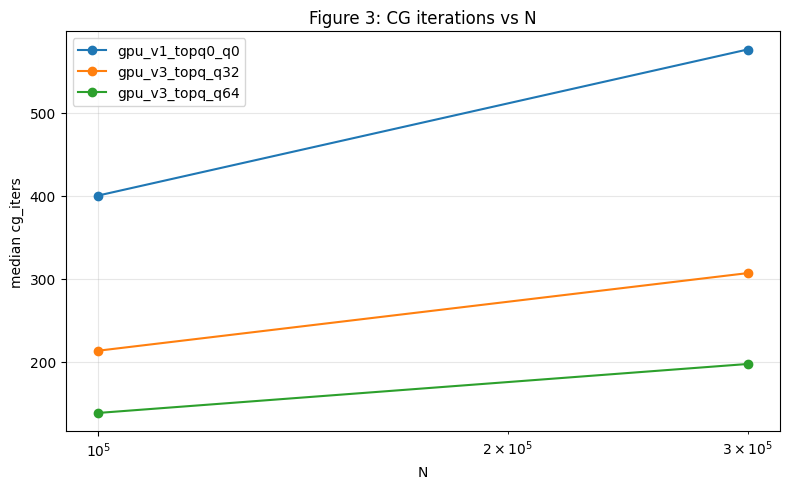

saved: outputs\weak_gpu_complexity_20260422_001236\plots\fig3_cg_iters_vs_n.png


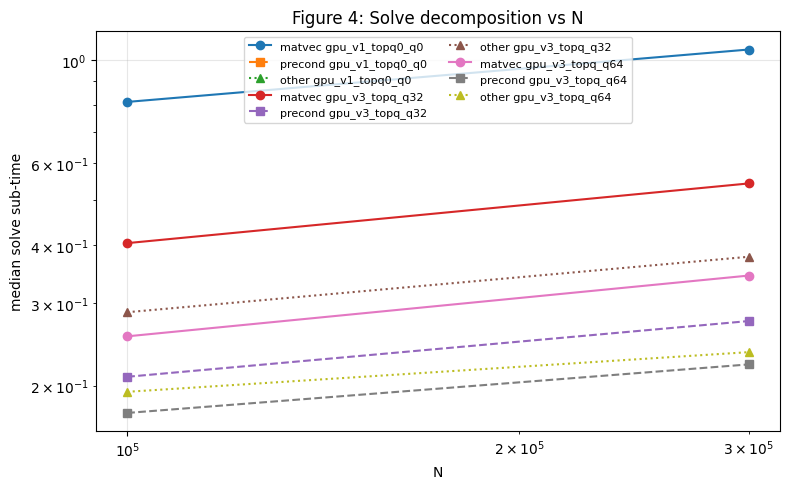

saved: outputs\weak_gpu_complexity_20260422_001236\plots\fig4_solve_decompose_vs_n.png


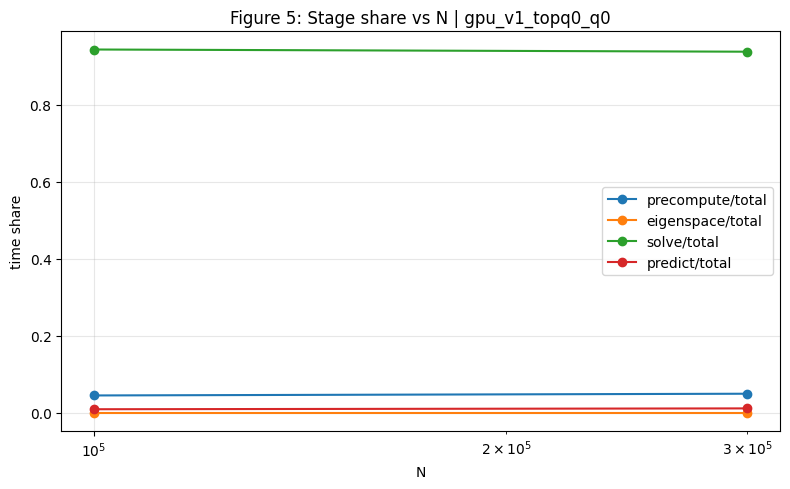

saved: outputs\weak_gpu_complexity_20260422_001236\plots\fig5_stage_share_gpu_v1_topq0_q0.png


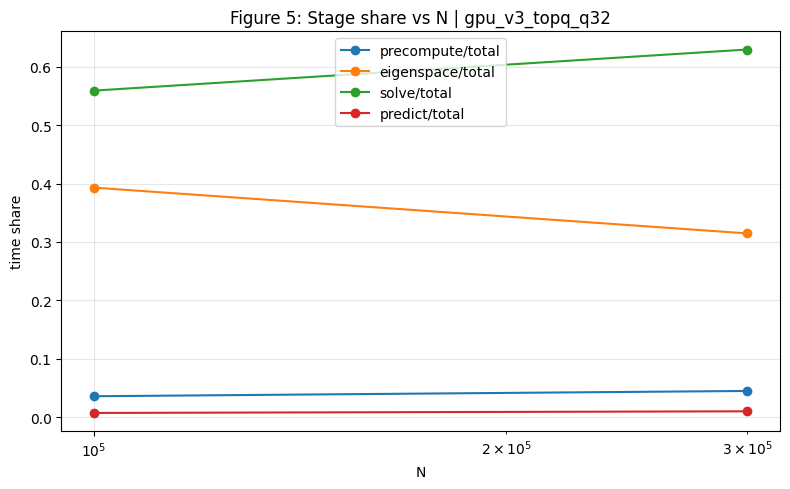

saved: outputs\weak_gpu_complexity_20260422_001236\plots\fig5_stage_share_gpu_v3_topq_q32.png


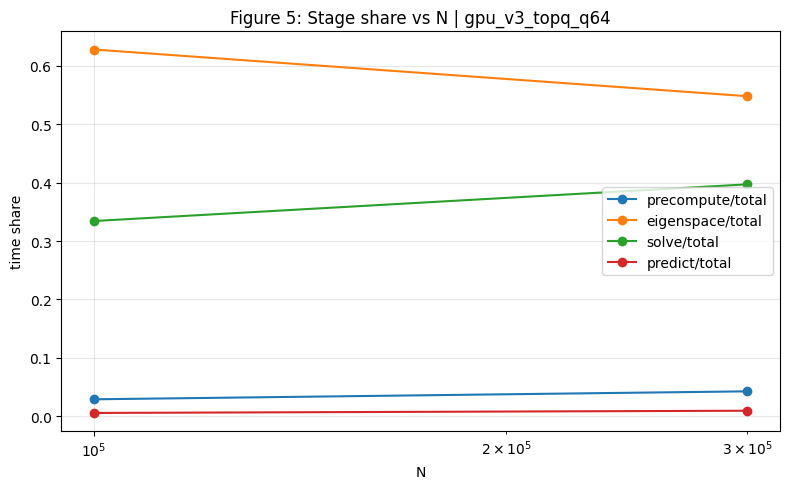

saved: outputs\weak_gpu_complexity_20260422_001236\plots\fig5_stage_share_gpu_v3_topq_q64.png
all plots saved in: outputs\weak_gpu_complexity_20260422_001236\plots


In [7]:
plot_dir = OUT_DIR / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)


def _label_of(row):
    return f"{row['mode']}_q{int(row['top_q'])}"


# Figure 1: end-to-end median wall time vs N (log-log)
fig, ax = plt.subplots(figsize=(8, 5))
for (mode, top_q), g in summary_df.groupby(["mode", "top_q"]):
    g = g.sort_values("N")
    ax.plot(g["N"], g["wall_s_total_median"], marker="o", label=f"{mode}_q{int(top_q)}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("N")
ax.set_ylabel("median wall_s_total")
ax.set_title("Figure 1: End-to-end time vs N")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig1_path = plot_dir / "fig1_total_time_vs_n_loglog.png"
fig.savefig(fig1_path, dpi=180)
plt.show()
print("saved:", fig1_path)


# Figure 2: stage time vs N by mode
for (mode, top_q), g in summary_df.groupby(["mode", "top_q"]):
    g = g.sort_values("N")
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(g["N"], g["time_precompute_median"], marker="o", label="precompute")
    ax.plot(g["N"], g["time_eigenspace_median"], marker="o", label="eigenspace")
    ax.plot(g["N"], g["time_solve_median"], marker="o", label="solve")
    ax.plot(g["N"], g["time_predict_median"], marker="o", label="predict")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("N")
    ax.set_ylabel("median stage time")
    ax.set_title(f"Figure 2: Stage time vs N | {mode}_q{int(top_q)}")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    p = plot_dir / f"fig2_stage_vs_n_{mode}_q{int(top_q)}.png"
    fig.savefig(p, dpi=180)
    plt.show()
    print("saved:", p)


# Figure 3: cg_iters vs N
fig, ax = plt.subplots(figsize=(8, 5))
for (mode, top_q), g in summary_df.groupby(["mode", "top_q"]):
    g = g.sort_values("N")
    ax.plot(g["N"], g["cg_iters_median"], marker="o", label=f"{mode}_q{int(top_q)}")
ax.set_xscale("log")
ax.set_xlabel("N")
ax.set_ylabel("median cg_iters")
ax.set_title("Figure 3: CG iterations vs N")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig3_path = plot_dir / "fig3_cg_iters_vs_n.png"
fig.savefig(fig3_path, dpi=180)
plt.show()
print("saved:", fig3_path)


# Figure 4: solve decomposition vs N
fig, ax = plt.subplots(figsize=(8, 5))
for (mode, top_q), g in summary_df.groupby(["mode", "top_q"]):
    g = g.sort_values("N")
    solve_other = g["time_solve_median"] - g["t_matvec_total_median"] - g["t_precond_total_median"]
    solve_other = solve_other.clip(lower=0)
    ax.plot(g["N"], g["t_matvec_total_median"], marker="o", linestyle="-", label=f"matvec {mode}_q{int(top_q)}")
    ax.plot(g["N"], g["t_precond_total_median"], marker="s", linestyle="--", label=f"precond {mode}_q{int(top_q)}")
    ax.plot(g["N"], solve_other, marker="^", linestyle=":", label=f"other {mode}_q{int(top_q)}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("N")
ax.set_ylabel("median solve sub-time")
ax.set_title("Figure 4: Solve decomposition vs N")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
fig4_path = plot_dir / "fig4_solve_decompose_vs_n.png"
fig.savefig(fig4_path, dpi=180)
plt.show()
print("saved:", fig4_path)


# Figure 5: time share vs N (per mode)
for (mode, top_q), g in summary_df.groupby(["mode", "top_q"]):
    g = g.sort_values("N")
    total = g["wall_s_total_median"].replace(0, np.nan)
    r_pre = g["time_precompute_median"] / total
    r_eig = g["time_eigenspace_median"] / total
    r_sol = g["time_solve_median"] / total
    r_pred = g["time_predict_median"] / total

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(g["N"], r_pre, marker="o", label="precompute/total")
    ax.plot(g["N"], r_eig, marker="o", label="eigenspace/total")
    ax.plot(g["N"], r_sol, marker="o", label="solve/total")
    ax.plot(g["N"], r_pred, marker="o", label="predict/total")
    ax.set_xscale("log")
    ax.set_xlabel("N")
    ax.set_ylabel("time share")
    ax.set_title(f"Figure 5: Stage share vs N | {mode}_q{int(top_q)}")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    p = plot_dir / f"fig5_stage_share_{mode}_q{int(top_q)}.png"
    fig.savefig(p, dpi=180)
    plt.show()
    print("saved:", p)

print("all plots saved in:", plot_dir)


In [ ]:
def _get_curve(df, mode, top_q):
    s = df[(df["mode"] == mode) & (df["top_q"] == top_q)].sort_values("N").copy()
    return s


v1 = _get_curve(summary_df, "gpu_v1_topq0", 0)
v3_qs = sorted([int(v) for v in summary_df.loc[summary_df["mode"] == "gpu_v3_topq", "top_q"].dropna().unique()])

print("=" * 80)
print("Q1: gpu_v1_topq0 的总时间随 N 如何增长")
if len(v1) >= 2:
    print(v1[["N", "wall_s_total_median", "local_alpha"]])
    print("Q1 observation: local_alpha 趋势见上表，可直接读 log-log 局部斜率。")
else:
    print("Q1 data insufficient")

print("=" * 80)
print("Q2: gpu_v3_topq 相对 gpu_v1_topq0 的快慢和拐点")
for q in v3_qs:
    v3 = _get_curve(summary_df, "gpu_v3_topq", q)
    m = v1.merge(v3, on=["N", "eps"], suffixes=("_v1", "_v3"))
    if m.empty:
        continue
    m["speedup_v1_over_v3"] = m["wall_s_total_median_v1"] / m["wall_s_total_median_v3"]
    m["v3_faster"] = m["speedup_v1_over_v3"] > 1.0
    print(f"top_q={q}")
    print(m[["N", "wall_s_total_median_v1", "wall_s_total_median_v3", "speedup_v1_over_v3", "v3_faster"]])

print("=" * 80)
print("Q3: 时间增长主要来自哪一段")
for (mode, top_q), g in summary_df.groupby(["mode", "top_q"]):
    g = g.sort_values("N").copy()
    for c in ["time_precompute_median", "time_eigenspace_median", "time_solve_median", "time_predict_median"]:
        g[f"ratio_{c}"] = g[c] / g["wall_s_total_median"].replace(0, np.nan)
    print(f"mode={mode}, top_q={int(top_q)}")
    print(g[["N", "ratio_time_precompute_median", "ratio_time_eigenspace_median", "ratio_time_solve_median", "ratio_time_predict_median"]])

print("=" * 80)
print("Q4: top_q>0 优势扩大还是缩小")
for q in v3_qs:
    v3 = _get_curve(summary_df, "gpu_v3_topq", q)
    m = v1.merge(v3, on=["N", "eps"], suffixes=("_v1", "_v3"))
    if m.empty:
        continue
    m["speedup_v1_over_v3"] = m["wall_s_total_median_v1"] / m["wall_s_total_median_v3"]
    print(f"top_q={q}, speedup trend")
    print(m[["N", "speedup_v1_over_v3"]])

print("=" * 80)
print("Artifacts")
print("raw csv:", RAW_CSV)
print("summary csv:", SUMMARY_CSV)
print("plots dir:", plot_dir)
print("env info:", ENV_JSON)


如果你在本地仓库直接运行（例如 `D:/NU/ML`），可以跳过 `## For github import` 单元，直接从导入单元开始执行。